In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

# QUESTION PART A
## Using the full 50 years of daily data:
1.	Choose and justify an appropriate shock definition/metric for this series.
2.	Calibrate 1-month, 3-month, and 6-month adverse shocks at the 90th, 95th, and 99th percentile severities.
3.	Compare the shocks across horizons and severities and explain the conclusions you draw.


## Part a

## Rolling Buy and Hold Analysis

#### 1.	Choose and justify an appropriate shock definition/metric for this series.


=== 1-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.008030  median=0.011533  skew=-0.738827  kurtosis(excess)=4.497664
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.1160 (-11.60%)  loss_mag: 0.1160
  p5:  -0.0651 (-6.51%)  loss_mag: 0.0651
  p10: -0.0437 (-4.37%)  loss_mag: 0.0437
Right-tail return quantiles (~90% / 95% / 99% gain levels):
  p90: 0.0553 (+5.53%)  gain_mag: 0.0553
  p95: 0.0711 (+7.11%)  gain_mag: 0.0711
  p99: 0.1135 (+11.35%)  gain_mag: 0.1135
Best / worst single-period return:
  Worst: -0.3167  Best: 0.2661

=== 3-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.024117  median=0.029003  skew=-0.541327  kurtosis(excess)=2.688787
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.2117 (-21.17%)  loss_mag: 0.2117
  p5:  -0.1020 (-10.20%)  loss_mag: 0.1020
  p10: -0.0648 (-6.48%)  loss_mag: 0.0648
Rig

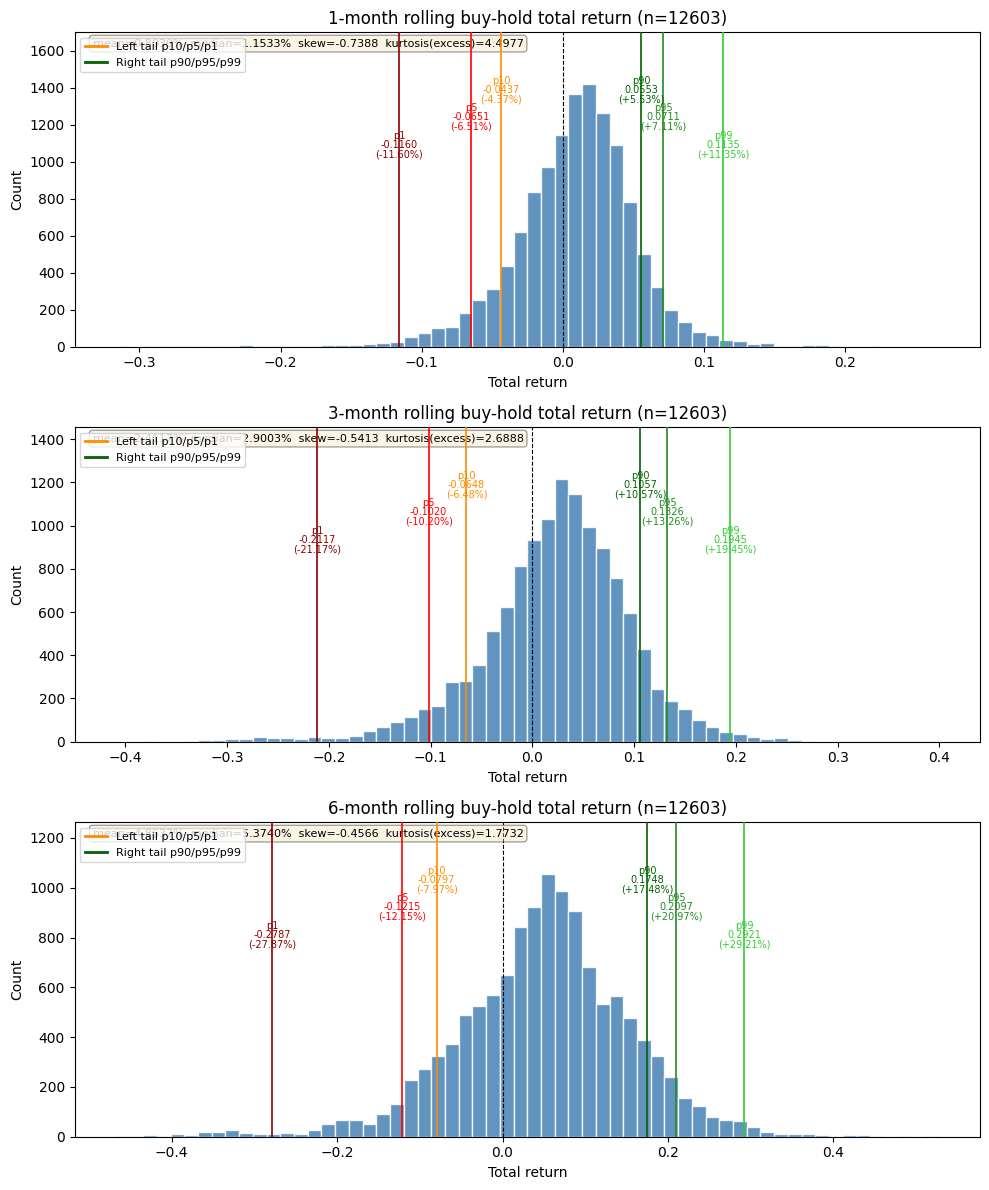

{'return_p1': -0.11601267569427189,
 'return_p5': -0.06511738096189126,
 'return_p10': -0.04369981368910305,
 'loss_magnitude_p99': 0.11601267569427189,
 'loss_magnitude_p95': 0.06511738096189126,
 'loss_magnitude_p90': 0.04369981368910305,
 'return_p90': 0.05529902757968329,
 'return_p95': 0.0711111161988406,
 'return_p99': 0.11346280066652063,
 'gain_magnitude_p90': 0.05529902757968329,
 'gain_magnitude_p95': 0.0711111161988406,
 'gain_magnitude_p99': 0.11346280066652063}

In [2]:
from spx_rolling_buyhold import analyze_spx_rolling, load_spx, rolling_calendar_month_returns, tail_loss_percentiles

out = analyze_spx_rolling()
out[1]["full_moments"]
#out[1]["right_tail_moments"]
out[1]["tail_metrics"]

## Drawdown Peak to Trough

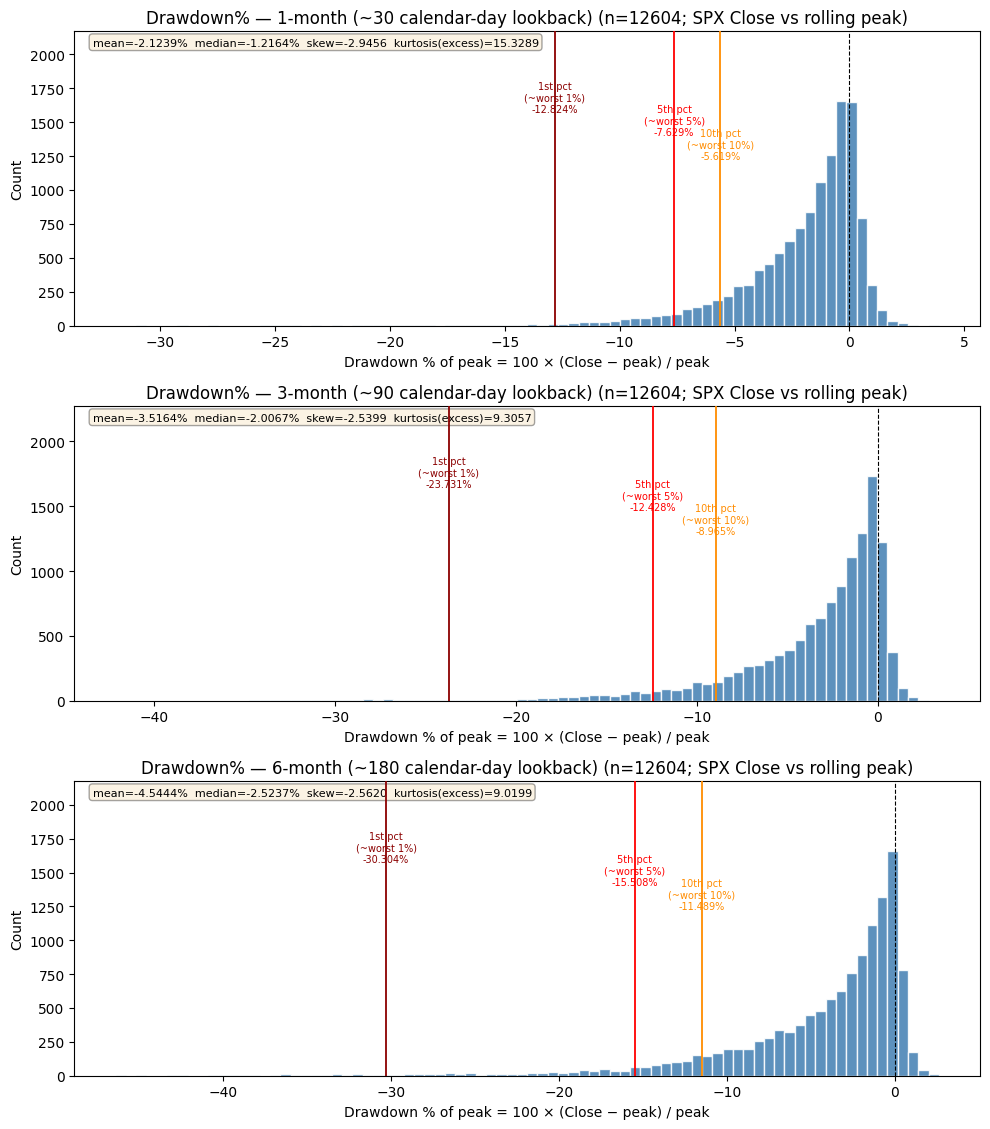

Worst-case tail: 1st / 5th / 10th pct of drawdown/peak (more negative = worse); ~99% / 95% / 90% of days are less severe. Moments on same series (fraction; ×100 = %).
  1M (~30d): n=12604  p1=-12.824%  p5=-7.629%  p10=-5.619%  |  mean=-2.1239%  median=-1.2164%  skew=-2.9456  kurtosis(excess)=15.3289
  3M (~90d): n=12604  p1=-23.731%  p5=-12.428%  p10=-8.965%  |  mean=-3.5164%  median=-2.0067%  skew=-2.5399  kurtosis(excess)=9.3057
  6M (~180d): n=12604  p1=-30.304%  p5=-15.508%  p10=-11.489%  |  mean=-4.5444%  median=-2.5237%  skew=-2.5620  kurtosis(excess)=9.0199


In [2]:
%matplotlib inline

from spx_drawdown_severity import analyze_spx_drawdown_percentiles

# ~1M / 3M / 6M: rolling peak over 30 / 90 / 180 calendar days (same as Part b/c DD).
out = analyze_spx_drawdown_percentiles(periods=(30, 90, 180))

In [3]:
{p: out[p]["moments"] for p in (30, 90, 180)}

{30: {'mean': -0.021239155440456826,
  'median': -0.012164039861657231,
  'skew': -2.9455518251049915,
  'kurtosis': 15.328943999823359,
  'n': 12604.0},
 90: {'mean': -0.035164373732890566,
  'median': -0.02006721085280458,
  'skew': -2.5398717263006985,
  'kurtosis': 9.30570799725303,
  'n': 12604.0},
 180: {'mean': -0.045444483645359676,
  'median': -0.025237487249806755,
  'skew': -2.562049502394202,
  'kurtosis': 9.019857901366795,
  'n': 12604.0}}

# ROBUSTNESS CHECKS & CONDITIONAL EVT (GARCH + GPD)

**Part (a) recipe:** (1) Fit **Student-t GARCH** on daily log returns from `spx_50yr.csv`. (2) Apply **POT / GPD** only to **standardized GARCH residuals** (not raw returns).

Plots: mean excess → parameter stability → fitted GPD → QQ → optional 1-day VaR.


In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from partb import compute_log_returns, fit_t_garch_on_daily, load_spx_daily #ok
from parta_evt import (
    conditional_var_one_day_log_return,
    fit_gpd_exceedances,
    gpd_qq_points,
    gpd_stability, 
    loss_from_std_residual, #ok
    mean_excess_curve, #ok
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)


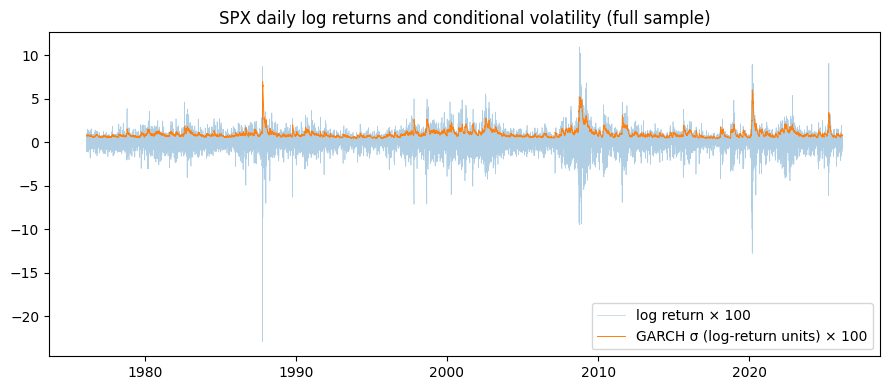

mu          0.065135
omega       0.012244
alpha[1]    0.083985
beta[1]     0.906880
nu          6.231559
Name: t-GARCH parameter, dtype: float64

In [11]:
daily = load_spx_daily()
r = compute_log_returns(daily)
garch = fit_t_garch_on_daily(daily, disp="off")

fig, ax = plt.subplots()
ax.plot(r.index, r * 100, alpha=0.35, lw=0.5, label="log return × 100")
ax.plot(
    garch.conditional_volatility.index,
    garch.conditional_volatility * 100,
    color="C1",
    lw=0.7,
    label="GARCH σ (log-return units) × 100",
)
ax.set_title("SPX daily log returns and conditional volatility (full sample)")
ax.legend()
plt.tight_layout()
plt.show()

pd.Series(garch.params, name="t-GARCH parameter")


### Getting the GPD parameters and Peak over Threshold values to create the GPD hybrid model

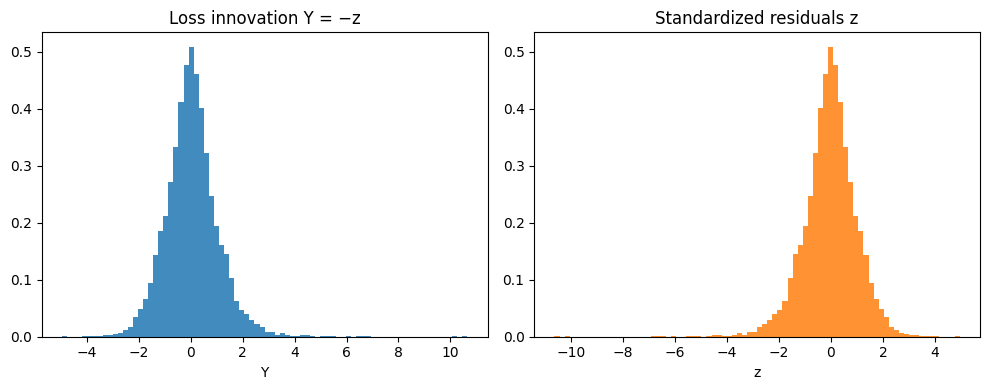

In [12]:
z = garch.standardized_residuals.dropna()
y = loss_from_std_residual(z)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y, bins=80, density=True, alpha=0.85)
axes[0].set_title("Loss innovation Y = −z")
axes[0].set_xlabel("Y")
axes[1].hist(z, bins=80, density=True, alpha=0.85, color="C1")
axes[1].set_title("Standardized residuals z")
axes[1].set_xlabel("z")
plt.tight_layout()
plt.show()


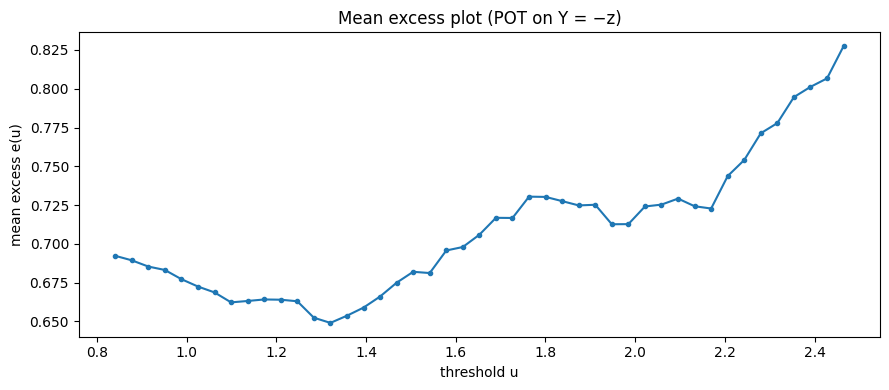

In [13]:
u_min = float(np.quantile(y, 0.82))
u_max = float(np.quantile(y, 0.985))
u_grid = np.linspace(u_min, u_max, 45)
mec = mean_excess_curve(y.values, u_grid, min_exceedances=15)

fig, ax = plt.subplots()
ax.plot(mec["u"], mec["mean_excess"], marker="o", ms=3)
ax.set_xlabel("threshold u")
ax.set_ylabel("mean excess e(u)")
ax.set_title("Mean excess plot (POT on Y = −z)")
plt.tight_layout()
plt.show()


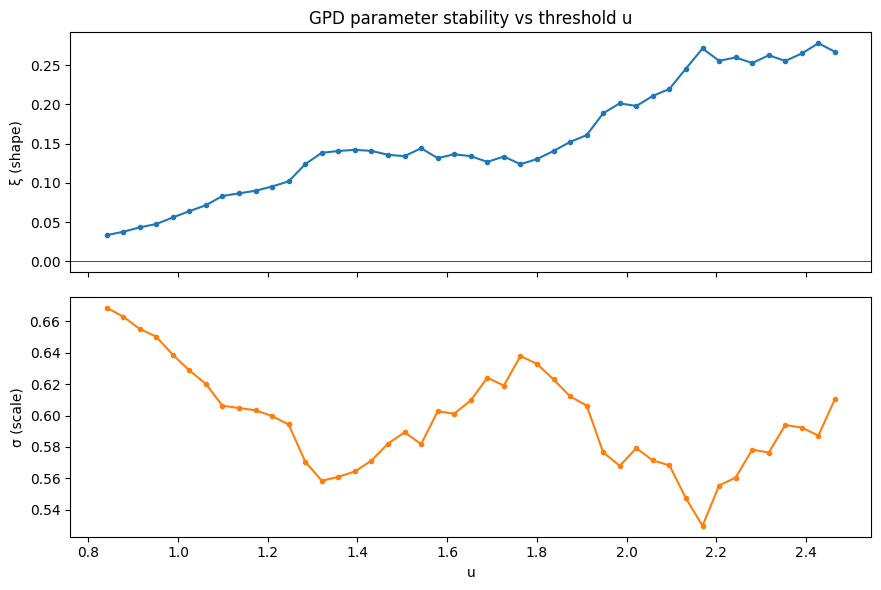

In [14]:
stab = gpd_stability(y.values, u_grid, min_exceedances=40)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].plot(stab["u"], stab["xi"], marker="o", ms=3)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("ξ (shape)")
axes[0].set_title("GPD parameter stability vs threshold u")
axes[1].plot(stab["u"], stab["sigma"], marker="o", ms=3, color="C1")
axes[1].set_ylabel("σ (scale)")
axes[1].set_xlabel("u")
plt.tight_layout()
plt.show()


**Threshold choice:** pick **u\*** where **ξ** and **σ** look stable (high enough to be in the tail; not so high that exceedances are noisy).

In [15]:
u_star = float(np.quantile(y, 0.92))
fit = fit_gpd_exceedances(y.values, u_star, min_exceedances=50)
w = y.values[y.values > u_star] - u_star
w = w[w > 0]

summary = pd.Series(
    {
        "u_star": fit.threshold,
        "n_exceedances": fit.n_exceedances,
        "xi (shape)": fit.xi,
        "sigma (scale)": fit.sigma,
    }
)
summary


u_star              1.412249
n_exceedances    1009.000000
xi (shape)          0.143965
sigma (scale)       0.564741
dtype: float64

### Checking the GPD fit - from below image the tail of the exceedances looks consistent with a GPD with your estimated ξ and σ (for that threshold).

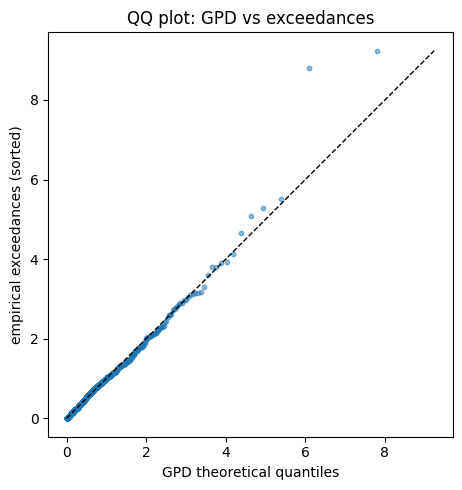

In [16]:
emp_qq, theo_qq = gpd_qq_points(w, fit.xi, fit.sigma)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(theo_qq, emp_qq, s=10, alpha=0.5)
lim = float(max(emp_qq.max(), theo_qq.max()))
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlabel("GPD theoretical quantiles")
ax.set_ylabel("empirical exceedances (sorted)")
ax.set_title("QQ plot: GPD vs exceedances")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


**One-day conditional VaR (illustrative):** GARCH **forecast** × **left tail of z** from the empirical–GPD hybrid on **Y = −z**.

In [17]:
fc = garch.fit.forecast(horizon=1, reindex=False)
mu_f = float(fc.mean.iloc[-1].iloc[0]) / garch.scale
sigma_f = float(np.sqrt(fc.variance.iloc[-1].iloc[0])) / garch.scale

alpha = 0.01
var_1d = conditional_var_one_day_log_return(
    mu_f, sigma_f, y.values, u_star, fit.xi, fit.sigma, alpha
)

pd.Series(
    {
        "mu_forecast (log return)": mu_f,
        "sigma_forecast (log return)": sigma_f,
        f"VaR_{int(100 * alpha)}% (loss, log-return units)": var_1d,
        "VaR × 100 (rough % points)": var_1d * 100,
    }
)


mu_forecast (log return)           0.000651
sigma_forecast (log return)        0.007974
VaR_1% (loss, log-return units)    0.021532
VaR × 100 (rough % points)         2.153161
dtype: float64

## What the Conditional EVT results mean

| Output | Meaning |
|--------|--------|
| **t-GARCH** | Time-varying daily **σ**; **t** innovations = fat tails. |
| **z (std. residuals)** | **(r−μ)/σ**; extremes modeled here, not raw **r**. |
| **Y = −z** | Large **Y** = bad day vs volatility; POT uses upper tail of **Y**. |
| **Mean excess** | Should trend **linear** in **u** if GPD tail is reasonable. |
| **ξ** | Tail shape: **>0** heavy, **=0** light, **<0** bounded. |
| **QQ plot** | On 45° line ⇒ GPD fits exceedances. |
| **1-day VaR cell** | Next-day **μ, σ** from GARCH × left tail of **z** (hybrid); units = **log return**. |

---

## 1M, 3M, 6M loss values — variable `horizon_evt`

Daily EVT does **not** give multi-month losses. **Run the next cell** for rolling **1/3/6-month** simple returns, **Y = −R**, GPD hybrid quantiles. **Find:** `horizon_evt`.


## Emperical Metrics comparable to robustness check using GPD on standardized residuals

In [1]:
import numpy as np
import pandas as pd

from parta_evt import fit_gpd_exceedances, hybrid_upper_quantile_y
from spx_rolling_buyhold import load_spx, rolling_calendar_month_returns, tail_loss_percentiles

px = load_spx()
rows = []
for m in (1, 3, 6):
    tab = rolling_calendar_month_returns(px, m)
    R = tab["return"].to_numpy(dtype=float)
    Y = -R
    emp = tail_loss_percentiles(R)
    u_star_h = float(np.quantile(Y, 0.92))
    fit_h = fit_gpd_exceedances(Y, u_star_h, min_exceedances=80)
    q99 = hybrid_upper_quantile_y(Y, u_star_h, fit_h.xi, fit_h.sigma, 0.99)
    q995 = hybrid_upper_quantile_y(Y, u_star_h, fit_h.xi, fit_h.sigma, 0.995)
    rows.append(
        {
            "horizon_m": m,
            "n": len(R),
            "empirical_return_p1": emp["return_p1"],
            "empirical_loss_mag_1pct_tail": emp["loss_magnitude_p99"],
            #"GPD_u": fit_h.threshold,
            #"GPD_xi": fit_h.xi,
            #"n_exceed": fit_h.n_exceedances,
            "hybrid_q99_loss_Y": q99,
            "hybrid_q99.5_loss_Y": q995,
        }
    )

horizon_evt = pd.DataFrame(rows)
horizon_evt


,horizon_m,n,empirical_return_p1,empirical_loss_mag_1pct_tail,hybrid_q99_loss_Y,hybrid_q99.5_loss_Y
0,1,12603,-0.116013,0.116013,0.123512,0.154324
1,3,12603,-0.211716,0.211716,0.196347,0.238925
2,6,12603,-0.278686,0.278686,0.250336,0.314570


# The Robusiness model is saying that a very severe downside move is about 12%–15% over 1 month, 20%–24% over 3 months, and 25%–31% over 6 months, depending on whether you look at the 99% or 99.5% tail. And Emperical results are comparable